In [ ]:
import numpy as np
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.impute import SimpleImputer
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [10]:
PROCESSED_DATA_PATH = '../data/processed/'

X_train_feat = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_train_feat.npy'))
y_train = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_train.npy'))
X_val_feat = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_val_feat.npy'))
y_val = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_val.npy'))
X_test_feat = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_test_feat.npy'))
y_test = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_test.npy'))


y_test_cat = to_categorical(y_test, num_classes=5)

print("Öznitelik matrisleri başarıyla yüklendi.")
print(f"Eğitim seti boyutu (önce): {X_train_feat.shape}")

# YENİ ADIM: NaN değerleri doldurma (Imputation)
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_feat)
X_val_imputed = imputer.transform(X_val_feat)
X_test_imputed = imputer.transform(X_test_feat)
print("NaN değerler sütun ortalamaları ile dolduruldu.")

# Standardizasyon adımını doldurulmuş veri üzerinden yap
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)
print("Veriler standardize edildi.")

Öznitelik matrisleri başarıyla yüklendi.
Eğitim seti boyutu (önce): (136883, 147)
NaN değerler sütun ortalamaları ile dolduruldu.
Veriler standardize edildi.


In [11]:
def suggest_lgbm_params(trial):
    params = {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 5, 'n_estimators': 1000, 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05), 'num_leaves': trial.suggest_int('num_leaves', 31, 128), 'max_depth': trial.suggest_int('max_depth', 6, 12), 'min_child_samples': trial.suggest_int('min_child_samples', 20, 100), 'feature_fraction': trial.suggest_float('feature_fraction', 0.7, 0.9), 'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 1.0, log=True), 'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 1.0, log=True), 'verbose': -1, 'n_jobs': -1, 'seed': 42}
    return params

def suggest_rf_params(trial):
    params = {'n_estimators': trial.suggest_int('n_estimators', 100, 300), 'max_depth': trial.suggest_int('max_depth', 10, 20), 'min_samples_split': trial.suggest_int('min_samples_split', 2, 10), 'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10), 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
    return params

def suggest_xgb_params(trial):
    params = {'objective': 'multi:softmax', 'num_class': 5, 'eval_metric': 'mlogloss', 'n_estimators': 1000, 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), 'max_depth': trial.suggest_int('max_depth', 3, 10), 'subsample': trial.suggest_float('subsample', 0.6, 1.0), 'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0), 'gamma': trial.suggest_float('gamma', 1e-8, 1.0, log=True), 'random_state': 42}
    return params

def suggest_sgd_params(trial):
    params = {'penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']), 'alpha': trial.suggest_float('alpha', 1e-4, 1e2, log=True), 'loss': 'log_loss', 'max_iter': 5000, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
    return params

# --- YENİ MODELİN PARAMETRE FONKSİYONU ---
def suggest_lsvc_params(trial): 
    params = {
        'C': trial.suggest_float('C', 1e-4, 1e2, log=True),
        'loss': 'squared_hinge',
        'max_iter': 5000, 
        'class_weight': 'balanced',
        'random_state': 42
    }
    return params
# --- ---

# --- YENİ MODEL LİSTESİ ---
models_to_tune = {
    "LightGBM": (lgb.LGBMClassifier, suggest_lgbm_params),
    "Random Forest": (RandomForestClassifier, suggest_rf_params),
    "XGBoost": (xgb.XGBClassifier, suggest_xgb_params),
    "SGD Classifier": (SGDClassifier, suggest_sgd_params),
    "LinearSVC": (LinearSVC, suggest_lsvc_params) # LR'yi bununla değiştirdik
}
# --- ---

results_list = []
MODELS_PATH = '../models/'
os.makedirs(MODELS_PATH, exist_ok=True)

for name, (model_class, suggest_params) in models_to_tune.items():
    print(f"\n--- {name} için süreç başlatılıyor ---")
    
    model_path = os.path.join(MODELS_PATH, f'tuned_{name.replace(" ", "_").lower()}.pkl')
    model_ready = False

    if os.path.exists(model_path):
        try:
            final_model = joblib.load(model_path)
            print(f"{name} modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...")
            model_ready = True
        except Exception as e:
            print(f"Uyarı: {model_path} dosyası var ancak bozuk. Model yeniden eğitilecek. (Hata: {e})")
            
    if not model_ready:
        print(f"{name} için Optimizasyon Başlatılıyor...")
        
        def objective(trial):
            params = suggest_params(trial)
            model = model_class(**params)
            
            if name == "LightGBM":
                model.fit(X_train_scaled, y_train,
                          eval_set=[(X_val_scaled, y_val)],
                          callbacks=[lgb.early_stopping(100, verbose=False)])
            else:
                model.fit(X_train_scaled, y_train)

            preds = model.predict(X_val_scaled)
            return balanced_accuracy_score(y_val, preds)

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=30) 

        print(f"--- {name} için Final Model Eğitiliyor ---")
        best_params = study.best_params
        
        if name == "SGD Classifier":
            best_params['loss'] = 'log_loss'; best_params['max_iter'] = 5000; best_params['class_weight'] = 'balanced'; best_params['random_state'] = 42; best_params['n_jobs'] = -1
        # --- YENİ MODEL İÇİN SABİT PARAMETRELER ---
        elif name == "LinearSVC":
            best_params['loss'] = 'squared_hinge'; best_params['max_iter'] = 5000; best_params['class_weight'] = 'balanced'; best_params['random_state'] = 42
        # --- ---
            
        final_model = model_class(**best_params)
        final_model.fit(X_train_scaled, y_train)
        joblib.dump(final_model, model_path)
        print(f"Optimize edilmiş {name} modeli kaydedildi.")

    # Her durumda test sonuçlarını hesapla
    # --- DİKKAT: LinearSVC 'predict_proba'yı DESTEKLEMEZ ---
    try:
        preds_proba = final_model.predict_proba(X_test_scaled)
        roc_auc_macro = roc_auc_score(y_test_cat, preds_proba, multi_class='ovr', average='macro')
    except AttributeError:
        print(f"  Uyarı: {name} 'predict_proba' metodunu desteklemiyor. ROC AUC 'None' olarak ayarlandı.")
        roc_auc_macro = None 
    # --- ---
    
    preds = final_model.predict(X_test_scaled)
    
    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_test, preds),
        'balanced_accuracy': balanced_accuracy_score(y_test, preds),
        'precision_macro': precision_score(y_test, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, preds, average='macro', zero_division=0),
        'f1_score_macro': f1_score(y_test, preds, average='macro', zero_division=0),
        'roc_auc_ovr_macro': roc_auc_macro
    }
    results_list.append(metrics)

# Scaler'ı kaydet (Orijinal Hücre 3'ün sonunda bu yoktu ama Hücre 2'de de yoktu, buraya eklemek en doğrusu)
scaler_path = os.path.join(MODELS_PATH, 'scaler.pkl')
imputer_path = os.path.join(MODELS_PATH, 'imputer.pkl')
if not os.path.exists(scaler_path): # Sadece sıfırdan oluşturulduysa kaydet
    joblib.dump(scaler, scaler_path)
    joblib.dump(imputer, imputer_path)
    print("Scaler ve Imputer 'models/' klasörüne kaydedildi.")


--- LightGBM için süreç başlatılıyor ---
LightGBM modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...
[LightGBM] [Warning] feature_fraction is set=0.8283828423740759, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8283828423740759
[LightGBM] [Warning] lambda_l2 is set=8.229712840175535e-08, reg_lambda=0.0 will be ignored. Current value: lambda_l2=8.229712840175535e-08
[LightGBM] [Warning] lambda_l1 is set=6.61924173367192e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.61924173367192e-05


/media/data/repo/anaconda3/envs/ecg-arrhythmia-detection/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/media/data/repo/anaconda3/envs/ecg-arrhythmia-detection/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.8283828423740759, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8283828423740759
[LightGBM] [Warning] lambda_l2 is set=8.229712840175535e-08, reg_lambda=0.0 will be ignored. Current value: lambda_l2=8.229712840175535e-08
[LightGBM] [Warning] lambda_l1 is set=6.61924173367192e-05, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.61924173367192e-05

--- Random Forest için süreç başlatılıyor ---
Random Forest modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...

--- XGBoost için süreç başlatılıyor ---
XGBoost modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...

--- SGD Classifier için süreç başlatılıyor ---
SGD Classifier modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...

--- LinearSVC için süreç başlatılıyor ---
LinearSVC modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...
  Uyarı: LinearSVC 'predict_proba' meto

In [12]:
results_df = pd.DataFrame(results_list)
results_df.set_index('model', inplace=True)

print("\n\n--- TÜM MODELLERİN KARŞILAŞTIRMALI SONUÇ TABLOSU (TEST SETİ) ---")
print(results_df.round(4))



--- TÜM MODELLERİN KARŞILAŞTIRMALI SONUÇ TABLOSU (TEST SETİ) ---
                accuracy  balanced_accuracy  precision_macro  recall_macro  \
model                                                                        
LightGBM          0.7969             0.7185           0.7924        0.7185   
Random Forest     0.8969             0.8390           0.9244        0.8390   
XGBoost           0.8715             0.8175           0.8851        0.8175   
SGD Classifier    0.6523             0.5958           0.5626        0.5958   
LinearSVC         0.6591             0.5907           0.5711        0.5907   

                f1_score_macro  roc_auc_ovr_macro  
model                                              
LightGBM                0.7488             0.9528  
Random Forest           0.8751             0.9881  
XGBoost                 0.8470             0.9802  
SGD Classifier          0.5713             0.8681  
LinearSVC               0.5739                NaN  


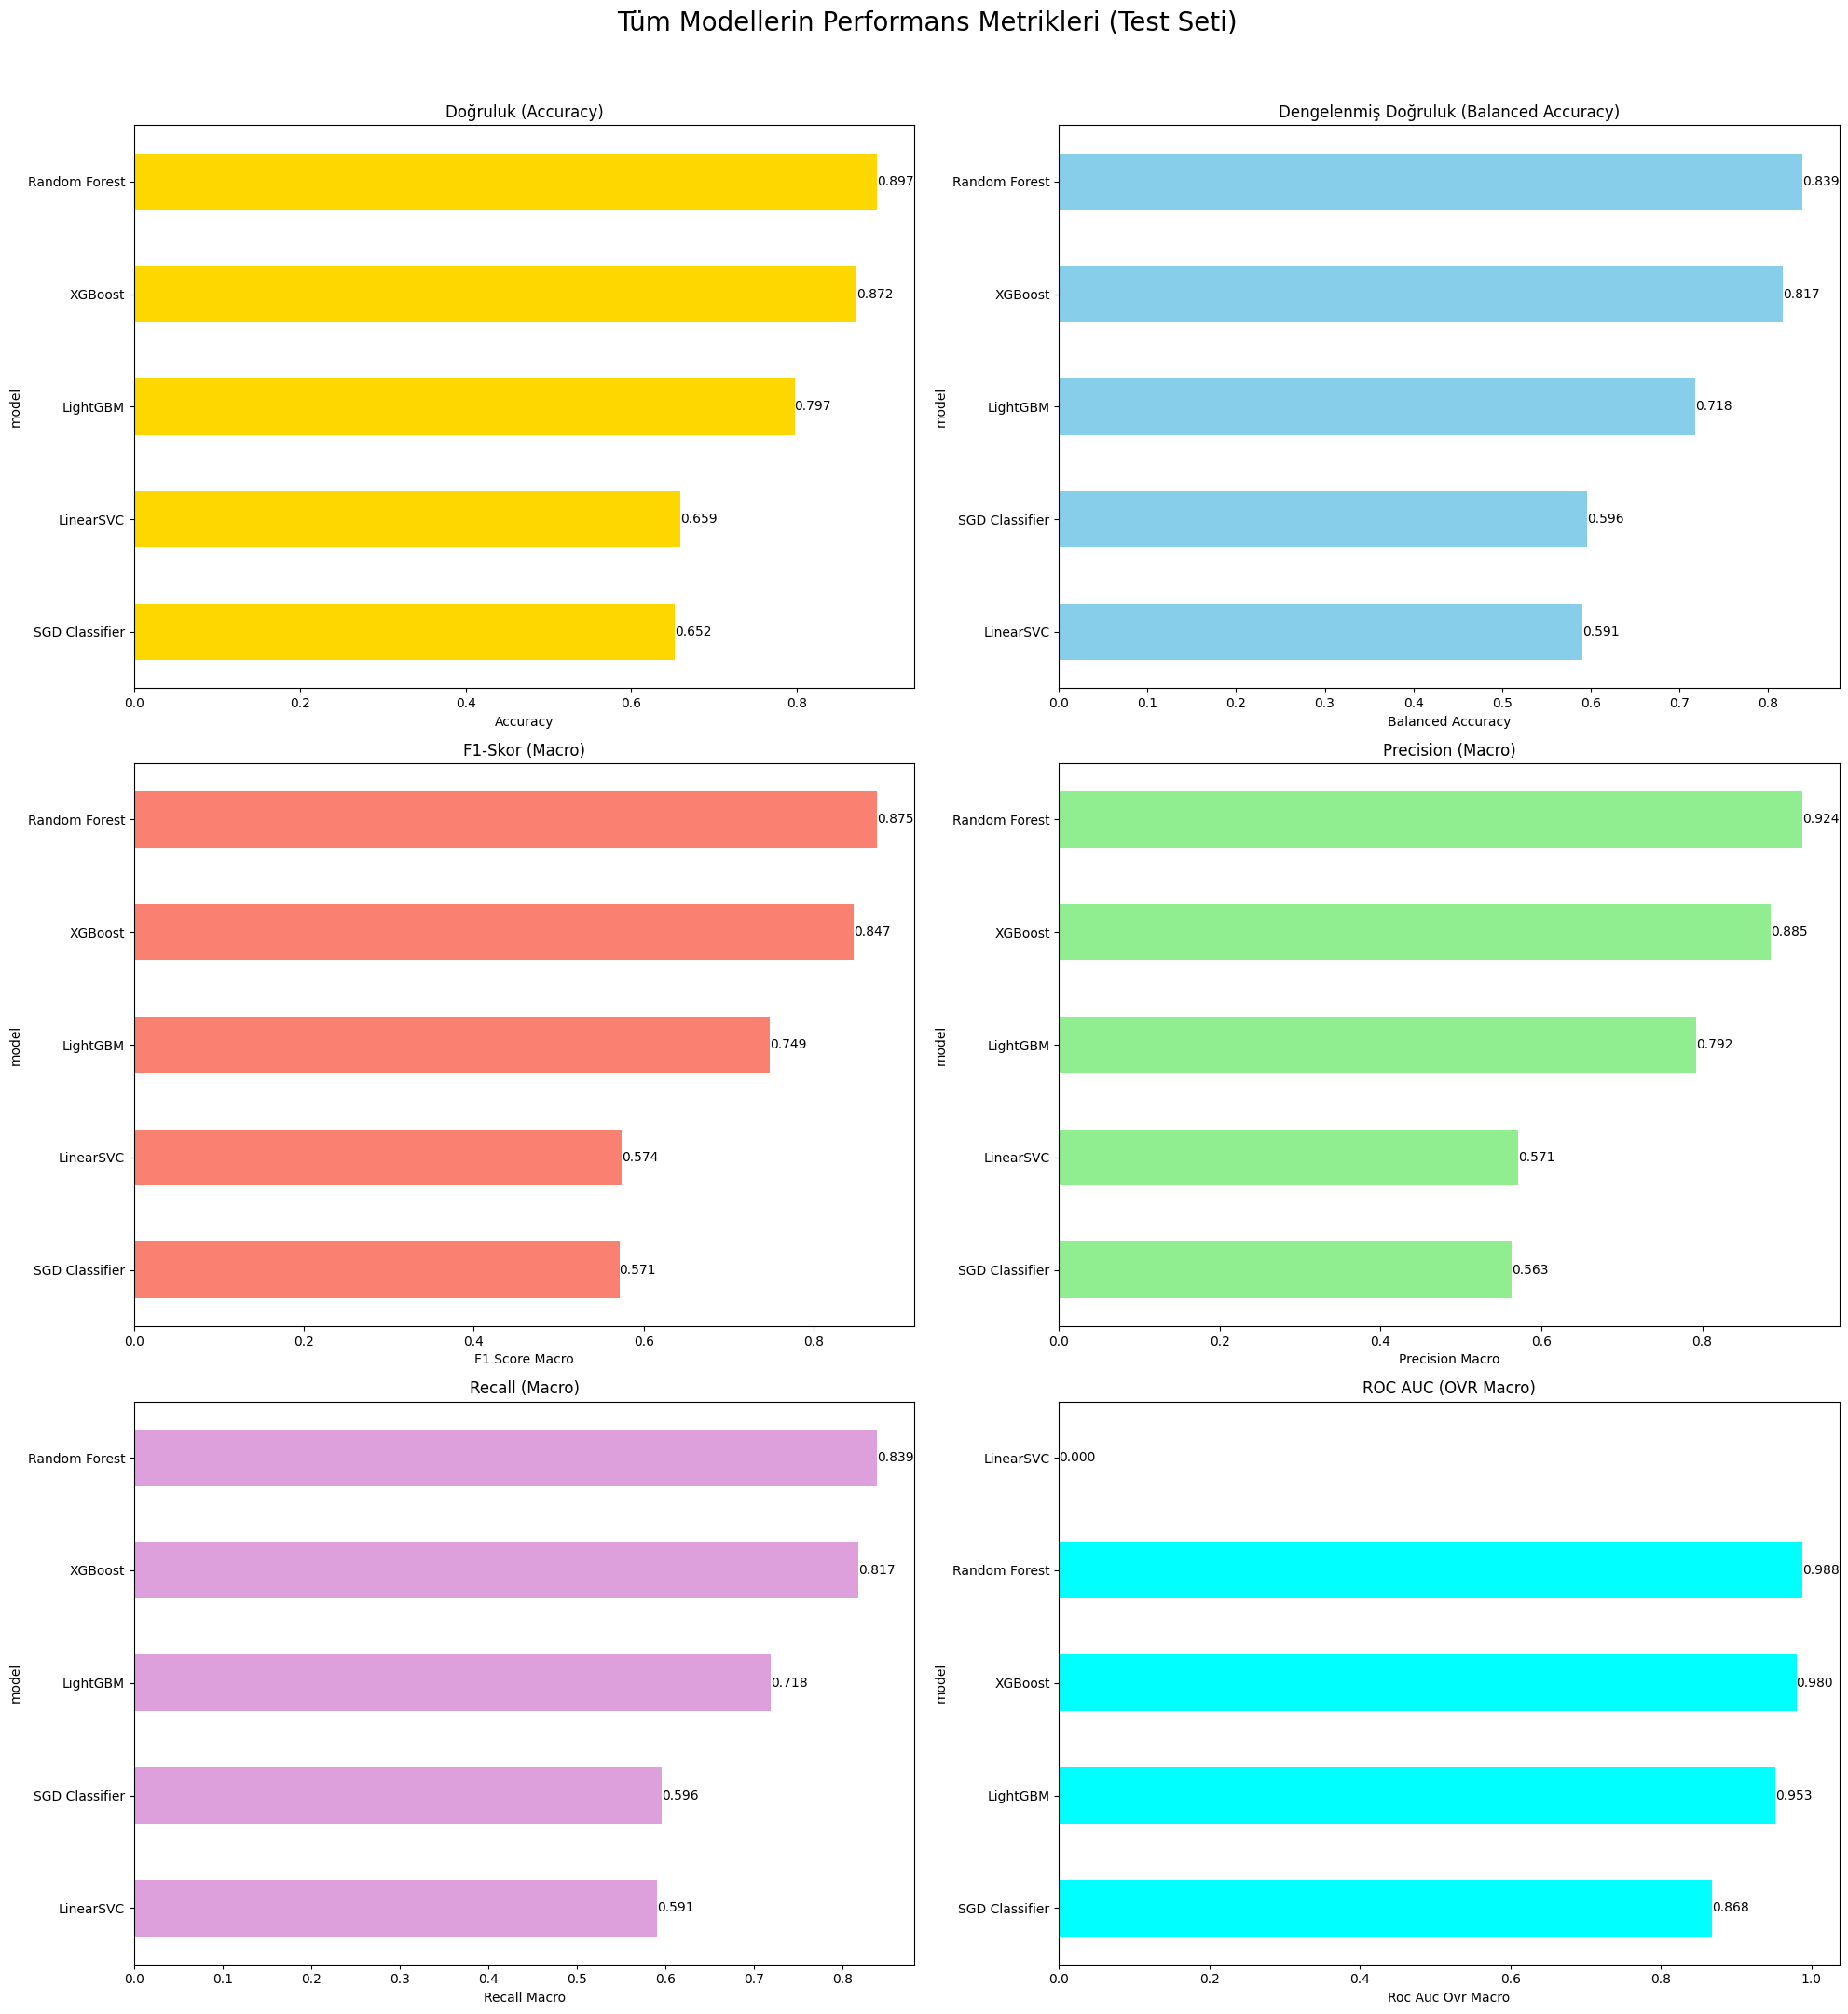

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(20, 22))
fig.suptitle('Tüm Modellerin Performans Metrikleri (Test Seti)', fontsize=20)
axes = axes.flatten() # 3x2 grid'i tek boyutlu bir diziye çevirir

metrics_to_plot = {
    'accuracy': 'Doğruluk (Accuracy)',
    'balanced_accuracy': 'Dengelenmiş Doğruluk (Balanced Accuracy)',
    'f1_score_macro': 'F1-Skor (Macro)',
    'precision_macro': 'Precision (Macro)',
    'recall_macro': 'Recall (Macro)',
    'roc_auc_ovr_macro': 'ROC AUC (OVR Macro)'
}
colors = ['gold', 'skyblue', 'salmon', 'lightgreen', 'plum', 'cyan']

for i, (metric, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    results_df[metric].sort_values().plot(
        kind='barh', ax=ax, color=colors[i], title=title
    )
    ax.set_xlabel(metric.replace('_', ' ').title())
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()